In [1]:
2 + 50

52

Activity:  By describing the conditions and putting the note in the top right, the author evokes morality and emotion.

In [2]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [3]:
#Load tips dataset.

tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

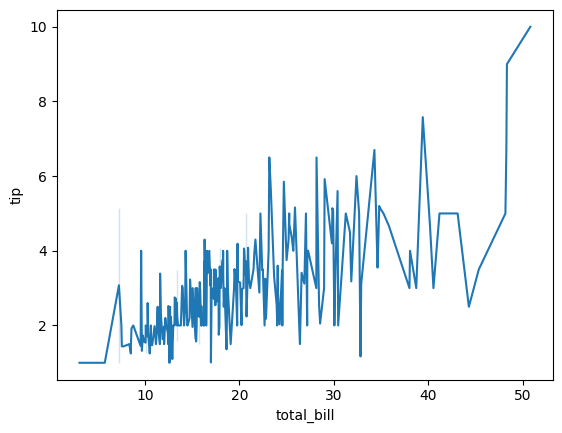

In [7]:
#Line plot.
sns.lineplot(data=tips, x='total_bill', y ='tip')


<Axes: xlabel='total_bill', ylabel='tip'>

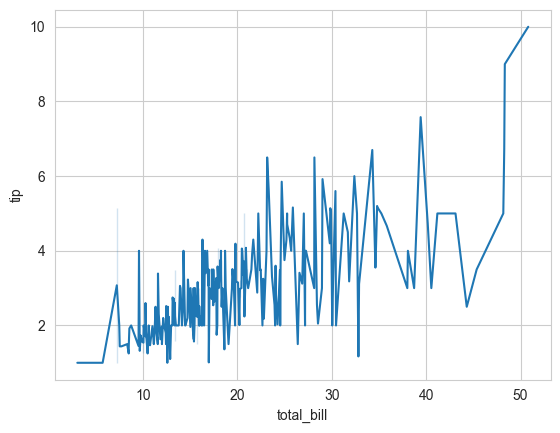

In [ ]:
#Line plot.
sns.set_style('whitegrid') #This must go before the plot line otherwise it fails. Can replace with other options like "dark".
sns.lineplot(data=tips, x='total_bill', y ='tip')


[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

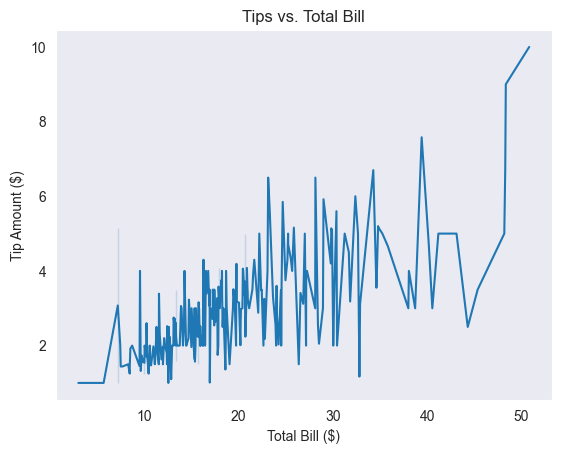

In [14]:
#Setting details like titles and axes. In order to use "set", it helps save your object with it's own name, so it knows where to apply.
sns.set_style('dark')
tipgraph = sns.lineplot(data=tips, x='total_bill', y='tip')
tipgraph.set(title='Tips vs. Total Bill', xlabel='Total Bill ($)', ylabel='Tip Amount ($)')


[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

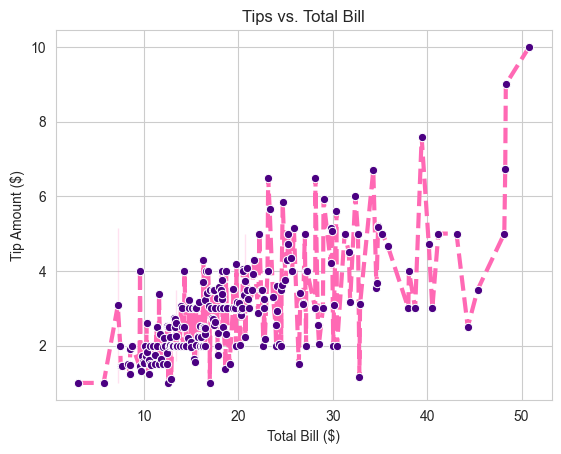

In [17]:
#Can modify more specifically.
sns.set_style('whitegrid')
tipgraph = sns.lineplot(data=tips,x='total_bill', y='tip',
color = 'hotpink',
linestyle = '--',
linewidth = 3,
marker = 'o',
markerfacecolor = 'indigo')

tipgraph.set(title='Tips vs. Total Bill', xlabel='Total Bill ($)', ylabel='Tip Amount ($)')

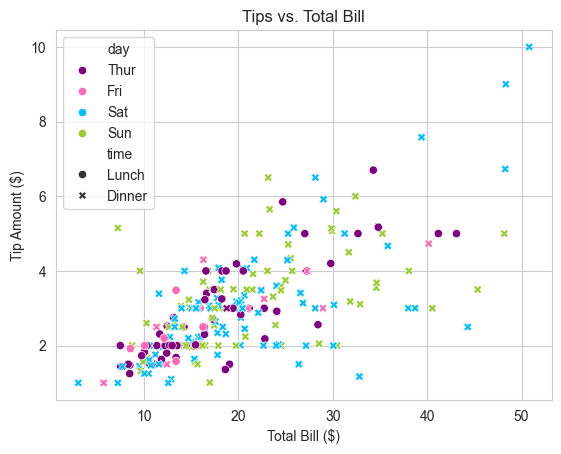

In [ ]:
#Seaborn allows different styles for different variables. This is one of the major benefits. Similar to ggplot (using scale or color).

tipgraph = sns.scatterplot(data=tips, x='total_bill', y='tip', 
style = 'time', #Assign different styles of markers to the levels of "time".
hue = 'day', #Assign different colours to the levels of "day".
palette = ['purple','hotpink', 'deepskyblue','yellowgreen']) #Specify the colours for each level. There is a default palette so this is not required unless you want specific colours.
tipgraph.set(title='Tips vs. Total Bill', xlabel='Total Bill ($)', ylabel='Tip Amount ($)')
#plt.legend(alignment="left") #There does not seem to be a way to change the alignment of the legend.
#This is actually a loop, making 8 scatterplots that are super imposed (Can do in MatLab, but have to manually do it all).

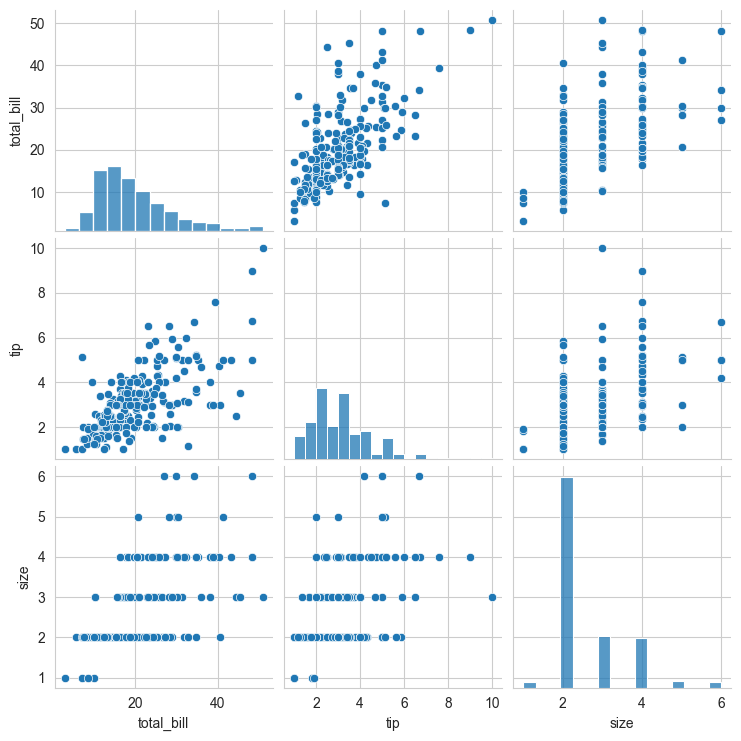

In [ ]:
#Pairplot compares variables for continuous variables (will not know how to pull the categorical variables). It will pull all possible columns if you don't specify.
#Useful for exploration and description.
sns.pairplot(data=tips)

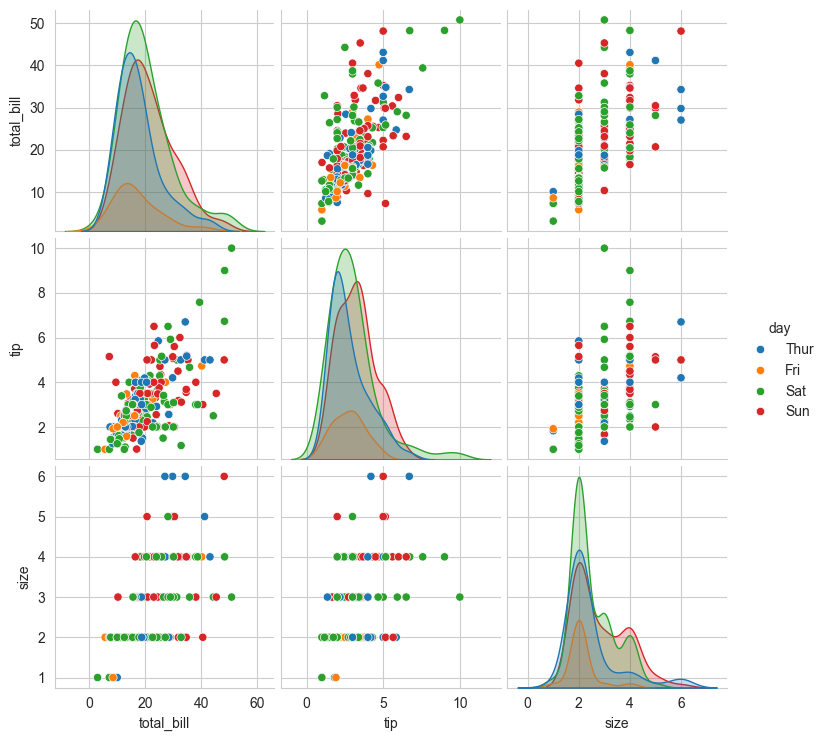

In [ ]:
#Can however, still specify style/colour by the categorical variables, though a graph will not be created.
sns.pairplot(data=tips, hue='day')

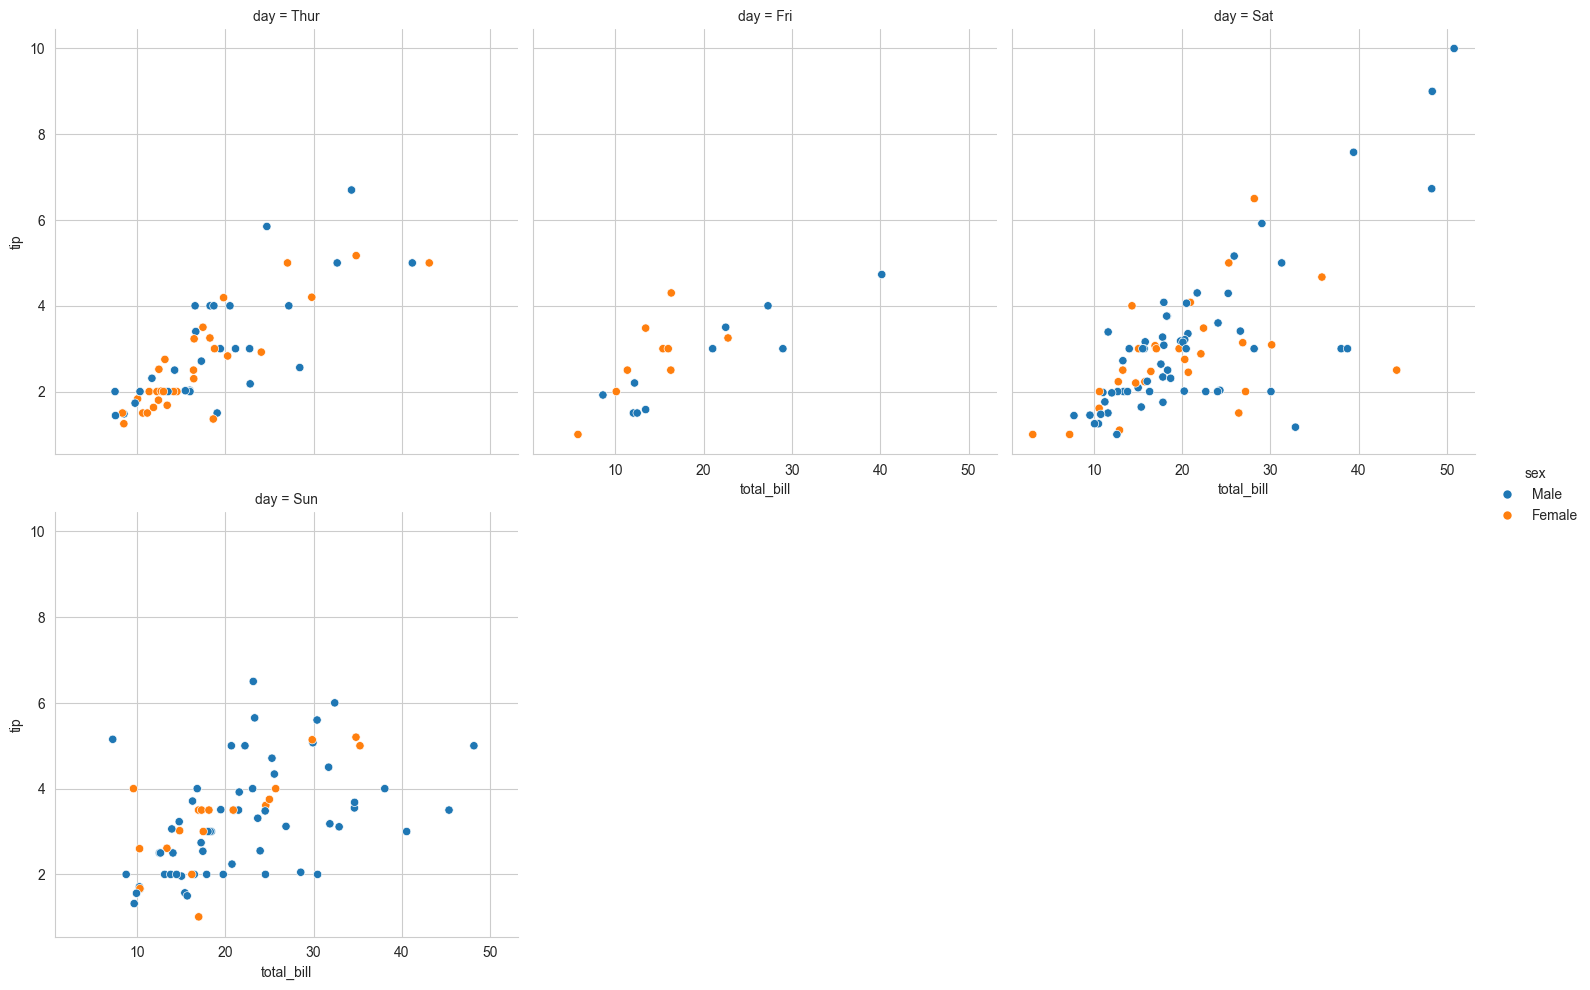

In [ ]:
#Another way to explore by levels of 2 different categorical variables.
daysplot = sns.relplot(data=tips, x="total_bill", y="tip",
hue="sex", #Add colour by specified variable.
col="day", #Have more columns, split by days (So can share another level this way).
kind="scatter", #Type of plot, could change to line, etc.
col_wrap=3) #Graphs per row.

Activity: Comparing the static and dynamic visualizations of rating by gender.
The dynamic one shows data at a more granular level, as you can see the different subjects results for particular words. However, it may be hard to get the high-level takeaway from the dynamic data.
The left data is simple and the message is easy to understand, but you know a lot less about the actual data.

Activity: Types of changes.
The language from rate my prof graph keeps the x axis constant but the order of the discipline in the y axis changes with different words. It could be immediate or transitional change depending on how much the y-axis changes. If the y-axis changes a lot, it would probably be immediate.

The spatial elements change a lot since the Y axes changes, and the data points themselves also change. The retinal elements are constant (e.g. the legend and color).

If it were up to me, I would always keep the y-axis the same for easier comparison of data.

In [27]:
#Using Plotly.

import plotly.graph_objects as go
from wordcloud import WordCloud
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

In [29]:
#Making variables.
x1 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

In [ ]:
#Make a blank figure object, and then add the plot to the figure.
graph = go.Figure()
graph.add_trace(go.Bar(x=x1, y=y1))

In [ ]:
#Since graph is an existing object, can alter in different chunks like so. Can update layout (e.g. add labels).
graph.update_layout(title="Pirate Scores", xaxis_title="Pirates", yaxis_title="Score")

#If you hover over the figure, you can find icons in the top right. Like pan, select, save, etc that modify the axes inside the figure.
#Maybe google with the select tool does. Can also download the plot.

#graph.write_html("pirategraph.html")
#This will make it save as a file and not open it in python.

#Can also make the graph show with graph.show()

In [ ]:
#Can customize in plotly in many ways, by using dictionaries as seen below.

graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1, mode='markers',  # we want points for a scatter plot, rather than another mode (e.g. lines)  
marker=dict(
size=15, # point size
color='hotpink', # point colour                   
opacity=1, # point transparency/alpha                         
line=dict(width=5, color='purple')  # point outline
)))
graph.update_layout(title='Interactive Pirate Plot', xaxis_title='Pirates',yaxis_title='Scores',
width=500, height=500) #Specify height and width.

#mode='markers'Scatter traces can draw:'markers' = points only ✅ (what you’re using), 'lines' = lines only, 'lines+markers' = both

In [37]:
#This is a way to specify some features within the Figure function, but this seems more complicated than the code above from the slides.
go.Figure(data=[go.Scatter(x=[1, 2, 3], y=[4, 1, 2])], layout=dict( width=800,)) # Set width in pixels height=500 # Set height in pixels ) )
                                                                    

In [ ]:
#Making word clouds.
from wordcloud import WordCloud

In [41]:
df = pd.read_csv("C:/Users/Elia/Dropbox/Data Sciences Certificate/visualization/02_activities/assignments/participation/movie_quotes.csv")
print(df)

                                                 quote  \
0                      Do, or do not. There is no try.   
1    Listen to them. Children of the night. What mu...   
2                              It's alive! It's alive!   
3    Oh, no, it wasn't the airplanes. It was Beauty...   
4    Magic Mirror on the wall, who is the fairest o...   
..                                                 ...   
727  I didn't know if you were lost. Stick with me....   
728  This guy's awesome! He's holding his own while...   
729     Murder is murder, it don’t matter who you are.   
730  You know what a lion is? A lion is a strong an...   
731  That was the best acting i've ever seen in my ...   

                                              movie   type  year  
0    Star Wars: Episode V - The Empire Strikes Back  movie  1890  
1                                           Dracula  movie  1931  
2                                      Frankenstein  movie  1931  
3                                  

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

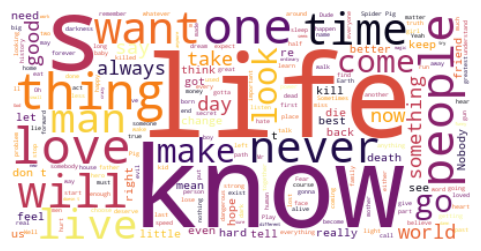

In [ ]:
# join all our text from each row from our quote column into a string
text = " ".join(each for each in df.quote)

# generate our wordcloud image
wordcloud = WordCloud(background_color="white", colormap = 'inferno').generate(text) #colormap is the color palette. Check for options online.

# use matplotlib syntax to put our image in a figure
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, # remember 'imshow' from when we added pictures to our matplotlib axes. This way it will actually show the wordcloud.                 
interpolation='bilinear') # this line helps smooth our image

ax.axis("off") #Remove axis.


In [44]:
#Can also make venn diagrams.
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

In [45]:
#Make the sets of data form diagram comparison.
A = set(["apple", "banana", "watermelon"])
B = set(["pumpkin", "blueberry", "apple", "key lime"])

c:\Users\Elia\Dropbox\Data Sciences Certificate\visualization\visualization-env\Lib\site-packages\matplotlib_venn\_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



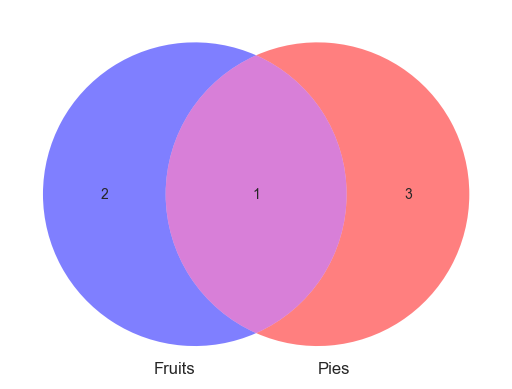

In [ ]:
#Make diagram, as for
diagram = venn2_unweighted([A, B],
set_labels = ('Fruits', 'Pies'),
set_colors=("blue", "red"),
alpha=0.5)

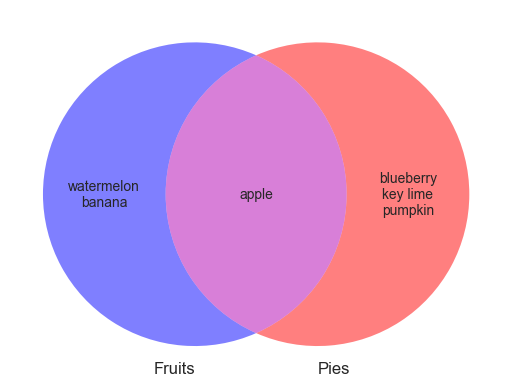

In [ ]:
diagram = venn2_unweighted([A, B],set_labels = ('Fruits', 'Pies'), set_colors=("blue", "red"),alpha=0.5)

#Labelling the different sections of the venn diagram. The id number is how you know which section is being referred to. See slides for a link to documentation
diagram.get_label_by_id("10").set_text("\n".join(A - B)) 
diagram.get_label_by_id("11").set_text("\n".join(A & B))
diagram.get_label_by_id("01").set_text("\n".join(B - A))